# **Proyecto Integrador: Avance 3. Baseline**  

## **Integrantes**
Ana Cristina Torres Cordero | A00831285  
Irene Plascencia Villalobos | A01625258  
Jorge Santana Mendoza | A01376306  

### **Fecha de entrega:** 24 de mayo del 2026

# **Contexto**

## **Problemática**
Los sistemas actuales de visión computacional para conteo de productos suelen estar diseñados para detectar objetos visibles. En escenarios de anaqueles con profundidad y apilamiento, esta formulación resulta insuficiente, ya que algunos productos pueden estar total o parcialmente ocultos por otros objetos, pero su existencia puede inferirse por continuidad estructural, repetición del patrón de acomodo, estimación de profundidad o geometría del stack.  
El problema central consiste en estimar el conteo amodal de productos en anaqueles cuando el conteo visible no coincide con el conteo real. El proyecto se enfoca en oclusiones estructurales derivadas de dos fenómenos principales: profundidad del anaquel y stacking de productos.  
Se busca desarrollar y evaluar una propuesta metodológica de visión computacional capaz de estimar el número total de productos en escenas de anaquel con oclusión estructural por profundidad y apilamiento. La propuesta deberá **integrar detección visible, estimación de profundidad y razonamiento espacial para inferir productos ocultos o parcialmente visibles** dentro de estructuras repetitivas de acomodo.

## **Objetivo del proyecto**  
Desarrollar y evaluar una propuesta de sistema de visión computacional basada en aprendizaje profundo para el conteo automático de productos en anaqueles bajo condiciones de oclusión, considerando una ruta progresiva desde el conteo visible hasta escenarios de conteo amodal e inferencia estructural.

# **Baseline: Explicación Teórica**

## **1. ¿Qué algoritmo se puede utilizar como baseline para predecir las variables objetivo?**  
Para este proyecto, el algoritmo propuesto como baseline es YOLO (You Only Look Once), un modelo de object detection ampliamente utilizado en visión computacional para detectar y localizar objetos en imágenes en tiempo real. YOLO divide la imagen en una cuadrícula y, en una sola pasada de la red neuronal, predice la ubicación de los objetos mediante bounding boxes,
la clase del objeto y la probabilidad de detección.  
YOLO es adecuado como baseline en este proyecto porque el objetivo principal es detectar y contar productos en anaqueles de retail a partir de imágenes tomadas desde una vista frontal e isométrica. En este contexto, **el modelo puede identificar cada producto visible dentro de la escena y posteriormente estimar el inventario mediante el conteo de detecciones realizadas**  

Una ventaja importante de YOLO es que permite trabajar directamente con escenas complejas de anaqueles, donde existen múltiples objetos por imagen, productos repetitivos, variaciones de iluminación y cierto nivel de oclusión parcial. Esto lo convierte en una base sólida para posteriormente comparar modelos más avanzados enfocados en profundidad, segmentación u oclusión

### **Implementación**
Para aplicar YOLO en este proyecto se seguirá el siguiente flujo:
1. **Construcción del dataset:** Capturar imágenes de anaqueles desde vista frontal y vista isométrica. Cada imagen tendrá anotaciones indicando la cantidad total de productos presentes.
2. **Entrenamiento del modelo:** Las imágenes anotadas se utilizarán para entrenar YOLO. El modelo aprenderá patrones visuales de los productos, formas, tamaños y posiciones dentro del anaquel.
3. **Proceso de detección:** Al ingresar una nueva imagen, YOLO detectará automáticamente los productos visibles, dibujará bounding boxes y asignará una predicción a cada objeto detectado.
4. **Conteo automático:** El número total de bounding boxes detectadas corresponderá al conteo estimado de productos. Este resultado se comparará contra el conteo real anotado en el dataset para evaluar precisión.
5. **Evaluación del baseline:** El desempeño se medirá utilizando métricas como mAP para detección, MAE para error de conteo y Recall para evaluar objetos omitidos.

## **2. ¿Se puede determinar la importancia de las características para el modelo generado?**  
Sí, es posible determinar la importancia de las características utilizadas por el modelo y analizar qué información visual contribuye más a la predicción.  
En este proyecto, la importancia de características puede evaluarse mediante técnicas de interpretabilidad como Grad-CAM, que permite visualizar qué regiones de la imagen utiliza el modelo para realizar el conteo o la detección de productos. Esto ayudaría a verificar si el modelo realmente se enfoca en los productos dentro del anaquel o si está aprendiendo patrones no deseados relacionados con iluminación, fondo o reflejos. Además, también puede realizarse un análisis comparativo utilizando únicamente la vista frontal, únicamente la vista isométrica o ambas perspectivas al mismo tiempo, con el objetivo de identificar cuál aporta mayor información para el conteo de productos y el manejo de oclusión.

## **3. ¿Cómo identificar si el modelo está sub/sobreajustando los datos de entrenamiento?**

El subajuste (underfitting) ocurre cuando el modelo no logra aprender correctamente los patrones presentes en los datos, mientras que el sobreajuste (overfitting) sucede cuando el modelo memoriza el conjunto de entrenamiento y pierde capacidad de generalización sobre nuevas imágenes. En proyectos de visión computacional con datasets propios, el sobreajuste suele ser uno de los principales riesgos, especialmente cuando existe poca variabilidad en iluminación, posiciones de cámara o tipos de productos.

Para identificar si el modelo presenta subajuste o sobreajuste, se comparará el desempeño obtenido en entrenamiento, validación y prueba utilizando métricas de detección y conteo. Si el modelo obtiene resultados muy buenos en entrenamiento pero significativamente peores en validación, esto indicaría sobreajuste. En cambio, si el desempeño es bajo tanto en entrenamiento como en validación, el modelo estaría subajustando los datos. También será importante analizar las curvas de pérdida (loss curves) durante el entrenamiento para observar el comportamiento de aprendizaje. Para reducir el riesgo de sobreajuste podrán utilizarse técnicas como aumento de datos (data augmentation), regularización, dropout y entrenamiento con imágenes capturadas en distintas condiciones y perspectivas.

## **4. ¿Cuál es la métrica adecuada para este problema de negocio?**

Debido a que el objetivo principal del proyecto es estimar correctamente la cantidad de productos presentes en un anaquel bajo condiciones de oclusión y stacking, la métrica más adecuada para evaluar el desempeño del sistema es el MAE (Mean Absolute Error), ya que permite medir directamente la diferencia promedio entre el conteo predicho por el modelo y el conteo real de productos.

El MAE es útil en este problema porque el objetivo final no es únicamente detectar objetos visibles, es estimar de forma precisa el inventario total presente en la escena. Un MAE bajo indicaría que el sistema realiza conteos cercanos a la realidad, incluso cuando existen productos parcialmente ocultos por stacking o profundidad del anaquel.

También se utilizarán métricas tradicionales de detección de objetos como mAP (mean Average Precision), precision y recall. El mAP permitirá evaluar la calidad de las detecciones realizadas por YOLO mediante bounding boxes, mientras que Recall será particularmente importante para medir cuántos productos visibles fueron omitidos por el modelo. Estas métricas complementan la evaluación del sistema, ya que permiten analizar tanto el desempeño de detección visible como la precisión del conteo total.

## **5. ¿Cuál debería ser el desempeño mínimo a obtener?**

Como baseline inicial del proyecto, se espera que el modelo YOLO logre detectar correctamente la mayoría de los objetos visibles dentro del anaquel, incluso bajo condiciones leves de oclusión, variaciones de iluminación y acomodo repetitivo.

Para considerar que el sistema tiene un desempeño mínimo aceptable, proponemos alcanzar un mAP mayor o igual a 0.7 en detección de productos visibles, un recall mayor o igual a 0.8 para reducir la cantidad de productos omitidos y un MAE menor o igual a 2 productos por imagen en el conteo real.

Estos valores se consideran adecuados para una primera aproximación baseline basada únicamente en detección visible, tomando en cuenta que el problema completo de conteo amodal incluye productos ocultos total o parcialmente, lo cual representa un reto adicional que YOLO por sí solo no resuelve completamente. Por lo tanto, en esta primera iteración se espera que los resultados no sean favorables.

El objetivo posterior será mejorar estos resultados mediante la incorporación de estimación de profundidad, razonamiento espacial e inferencia estructural para aproximarse al conteo real de productos en escenarios con stacking y profundidad de anaquel.

# **Baseline: Aplicación práctica**

## 1. Conectar con drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Instalar YOLO

In [2]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.0 MB/s eta 0:00:00


## 3. Importar las librerías a utilizar

In [ ]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 4. Carpetas necesarias para trabajar con YOLO

In [ ]:
base_path = Path("/content/drive/MyDrive/producto_amodal/dataset") #DATASET

#Carpetas necesarias para ejecutar YOLO
folders = [
    "images/train", #Imagenes de entrenamiento
    "images/val", #Imagenes de validación
    "images/test", #Imagenes de prueba
    "labels/train", #Anotaciones de entrenamiento
    "labels/val", #Anotaciones de validación
    "labels/test" #Anotaciones de prueba
]

#Recorre cada carpeta de la lista
for folder in folders:
    #Crea la carpeta automáticamente y evita los errores en caso de que ya existan
    (base_path / folder).mkdir(parents=True, exist_ok=True)

print("Carpetas creadas correctamente")#Confirmación

## 5. Crear archivo data.yaml

In [ ]:
#Este archivo le dice a YOLO: Dónde está el dataset, las carpetas a usar y las clases que existen
data_yaml = f"""

path: {base_path} #Dataset

train: images/train #Carpeta de imágenes entrenamiento
val: images/val #Carpeta de imágenes validación
test: images/test # Carpeta de imágenes prueba

Clases del proyecto
names:
  Clase 0 = producto
  0: producto

"""

yaml_path = base_path / "data.yaml" #Path del archivo YAML

with open(yaml_path, "w") as f: #Abre el archivo en modo escritura
    f.write(data_yaml) #Escribe el contenido YAML

print("data.yaml creado correctamente")#Confirmación
print(yaml_path) #Imprime ubicación del archivo

## 6. Entrenar modelo YOLO

In [ ]:
model = YOLO("yolov8n.pt")

#Entrena el modelo
results = model.train(

    data=str(yaml_path), #Archivo YAML del dataseT
    epochs=50, #Número de épocas de entrenamiento
    imgsz=640, #Tamaño de imagen usado por YOLO
    batch=8, # Cantidad de imágenes por batch

    project="/content/drive/MyDrive/producto_amodal/runs", #Carpeta donde guardar resultados

    name="baseline_yolo_visible" #Nombre
)

print("Entrenamiento terminado") #Confirmación

## 7. Cargar el mejor modelo entrenado

In [ ]:
#Path del mejor modelo generado
best_model_path = (
    "/content/drive/MyDrive/producto_amodal/"
    "runs/baseline_yolo_visible/weights/best.pt"
)

model = YOLO(best_model_path) #Modelo entrenado
print("Modelo cargado correctamente") #Confirmación


## 8. Validar Modelo

In [ ]:
#Evalúa el modelo usando imágenes de test
metrics = model.val(
    data=str(yaml_path), #Dataset YAML
    split="test" #Utilizar split de prueba
)

# Imprime métricas (mAP, precision, recall, etc.):
print(metrics)

## 9. Hacer predicciones y contar productos

In [ ]:
test_images_dir = Path("/content/drive/MyDrive/producto_amodal/dataset/images/test") #Imágenes de prueba
predictions = [] #Lista de predicciones

for img_path in test_images_dir.glob("*"): #Recorre todas las imágenes de test
    if img_path.suffix.lower() not in [ # Ignora archivos que no sean imagenes
        ".jpg",".jpeg",".png"
    ]:
        continue

    #Hace la predicción sobre la imagen
    result = model.predict(
        source=str(img_path), #Imagen
        conf=0.25, #Umbral de confianza mínimo
        save=False, #No guardar imágenes predichas
        verbose=False #No mostrar logs detallados

    )[0] # [0] Toma el primer resultado

    visible_count = len(result.boxes) #Conteo de la cantidad de bounding boxes detectadas
    predictions.append({ # Guarda resultados en lista
        "image": img_path.name, #Nombre de imagen
        "visible_count_yolo": visible_count #Conteo visible detectado por YOLO
    })

pred_df = pd.DataFrame(predictions) #Convertir lista a DataFrame

print(pred_df)


## 10. Cargar el conteo real y comparar predicciones con lo real

In [ ]:
counts_path = ("/content/drive/MyDrive/producto_amodal/counts.csv") #Path del CSV con conteos reales
true_df = pd.read_csv(counts_path) #Leer CSV usando pandas

print(true_df.head()) #Muestra primeras filas

#Predicción vs realidad
eval_df = pred_df.merge(
    true_df, #Tabla real
    on="image", #Unir usando columna image
    how="inner" # Solo coincidencias
)

#Error (predicción vs realidad)
eval_df["error"] = (eval_df["visible_count_yolo"] - eval_df["total_count"])

#Error absoluto
eval_df["abs_error"] = (eval_df["error"].abs())

print(eval_df) #Resultados

## 11. Caldular MAE (Mean Absolute Error)

In [ ]:
#Promedio del error absoluto
mae = eval_df["abs_error"].mean()

print("MAE DE CONTEO:", mae)

# **PRUEBA CON SKU-110K:**
Debido a que seguimos consolidando el dataset construido manualmente, decidimos probar la implementación de YOLO con imágenes de anaqueles obtenidas de este dataset ya existente encontrado en nuestra investigación. Esto con el fin de tener una base sólida, donde podamos empezar a preparar la implementación de YOLO para el posterior desarrollo de la sección de conteo amodal.

## 1. Conectar con drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Instalar YOLO

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00


## 3. Importar las librerías a utilizar

In [ ]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

## 4. Entrenar modelo YOLO con SKU-110K

In [ ]:
#Carga YOLO
model = YOLO("yolov8n.pt")

#Entrenamiento de prueba con dataset de anaqueles
results = model.train(
    data="SKU-110K.yaml",   #Dataset retail
    epochs=3,              #Prueba rápida
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/producto_amodal/runs",
    name="prueba_sku110k"
)

print("Entrenamiento con SKU-110K terminado")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=SKU-110K.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=prueba_sku110k-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

## 5. Cargar el mejor modelo entrenado

In [ ]:
best_model_path = "/content/drive/MyDrive/producto_amodal/runs/prueba_sku110k-2/weights/best.pt"
model = YOLO(best_model_path)
print("Modelo SKU-110K cargado correctamente")

Modelo SKU-110K cargado correctamente


## 6. Validar Modelo

In [ ]:
#Evalúa el modelo usando imágenes de test
metrics = model.val(
    data="SKU-110K.yaml", #Dataset YAML
    split="val" #Utilizar split de prueba
)

print(metrics)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2269.3±948.3 MB/s, size: 1181.6 KB)
val: Scanning /content/datasets/SKU-110K/labels.cache... 588 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 588/588 189.7Mit/s 0.0s
val: /content/datasets/SKU-110K/images/val_0.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_115.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_127.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_166.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_172.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_190.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/val_2.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110

## 7. Hacer predicciones

In [ ]:
#Imagen en nuestro drive
img = Image.open("/content/drive/MyDrive/Pruebas Avance 3 Proyecto Integrador/Prueba.jfif")
img.save("/content/drive/MyDrive/Pruebas Avance 3 Proyecto Integrador/Prueba.jpg")

In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/Pruebas Avance 3 Proyecto Integrador/Prueba.jpg",
    save=True,
    conf=0.25,
    name="prediccion_retail",
    exist_ok=True,

    show_labels=False, #NO mostrar nombres/clases
    show_conf=False, #NO mostrar confidence
    line_width=3 #Grosor
)



image 1/1 /content/drive/MyDrive/Pruebas Avance 3 Proyecto Integrador/Prueba.jpg: 640x480 145 objects, 6.6ms
Speed: 2.8ms preprocess, 6.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/prediccion_retail


## 8. Mostrar imagen con boxes

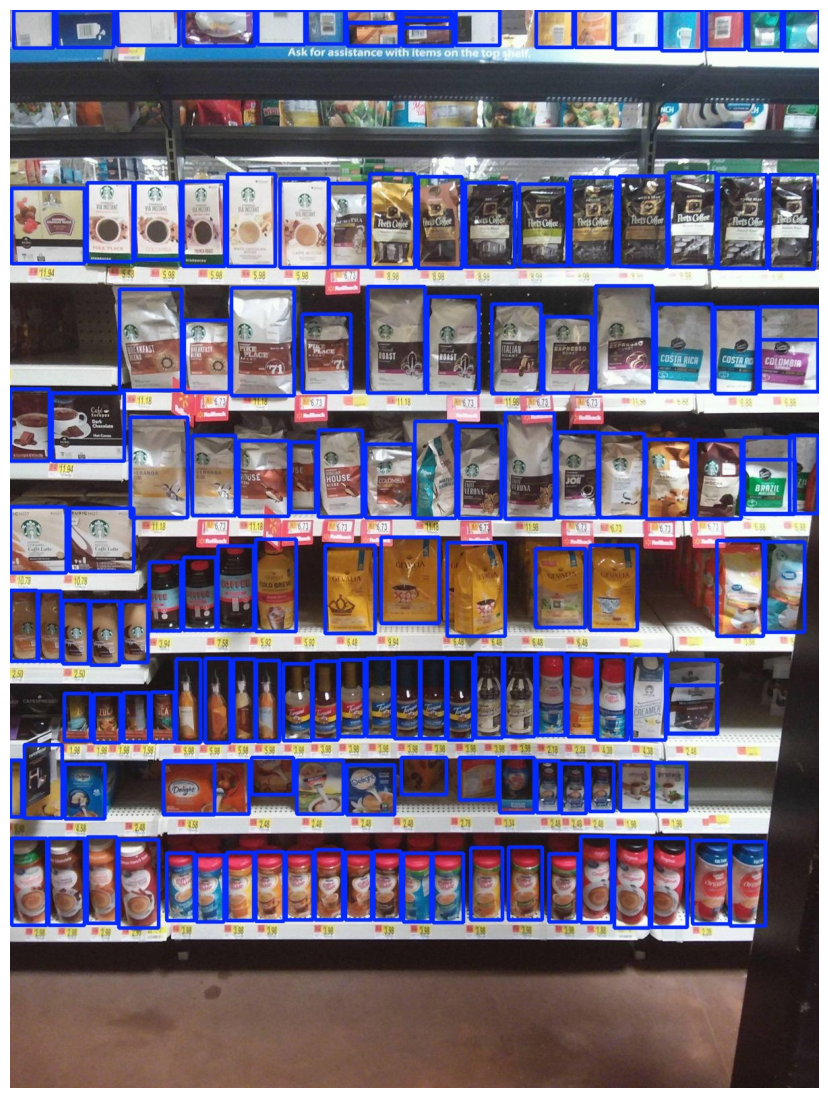

In [ ]:
img_path = Path("runs/detect/prediccion_retail/Prueba.jpg")
img = Image.open(img_path)

plt.figure(figsize=(14,14))
plt.imshow(img)
plt.axis("off")
plt.show()

## 9. Contar productos

In [ ]:
#Toma el primer resultado
result = results[0]

#Cuenta cuántas cajas detectó YOLO
visible_count = len(result.boxes)

print("Productos/objetos detectados:", visible_count)

Productos/objetos detectados: 145


# **PRUEBA CON DATASET PROPIO:**
En esta sección se realiza una prueba inicial con una imagen propia capturada en un anaquel con productos reales. El objetivo es validar el flujo de inferencia usando YOLO, desde la carga de la imagen hasta la obtención de las predicciones en formato tabular.

La imagen utilizada contiene productos colocados sobre un anaquel, incluyendo objetos apilados y productos con posible oclusión parcial. Esta prueba permite observar las limitaciones de un modelo YOLO preentrenado cuando se aplica a un dominio específico como productos de retail.

Es importante mencionar que el modelo yolov8n.pt está preentrenado con clases generales del dataset COCO, por lo que no necesariamente reconocerá marcas o productos específicos como jabones, aromatizantes o envases comerciales. Esta prueba se utiliza como validación funcional del pipeline de predicción, no como evaluación definitiva del desempeño del sistema. Ultralytics permite ejecutar inferencia con model.predict() y extraer las cajas, clases y confianzas desde el objeto results.

## 1. Carga del modelo YOLO

In [3]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Carga YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Carga de la imagen propia

In [4]:
from google.colab import files

uploaded = files.upload()

image_path = Path(list(uploaded.keys())[0])
print("Imagen cargada:", image_path)

Saving SCN_149_A0_front.jpg to SCN_149_A0_front.jpg
Imagen cargada: SCN_149_A0_front.jpg


## 3. Visualización de la imagen original

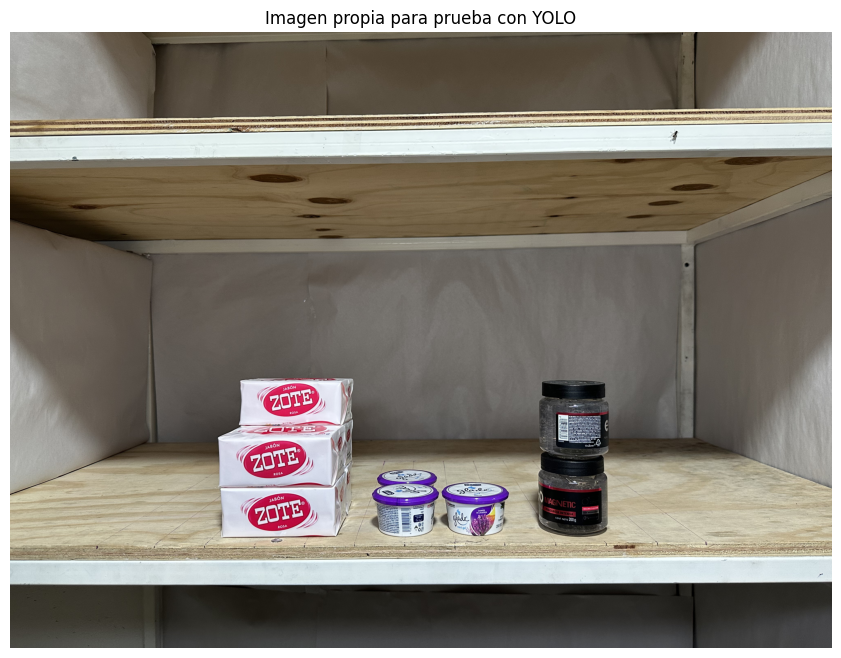

In [5]:
img = Image.open(image_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Imagen propia para prueba con YOLO")
plt.show()

## 4. Predicción con YOLO

In [6]:
results = model.predict(
    source=str(image_path),
    conf=0.25,
    iou=0.45,
    save=True
)

result = results[0]


image 1/1 /content/SCN_149_A0_front.jpg: 480x640 1 bottle, 1 cake, 153.6ms
Speed: 14.8ms preprocess, 153.6ms inference, 85.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


## 5. Visualización de predicciones

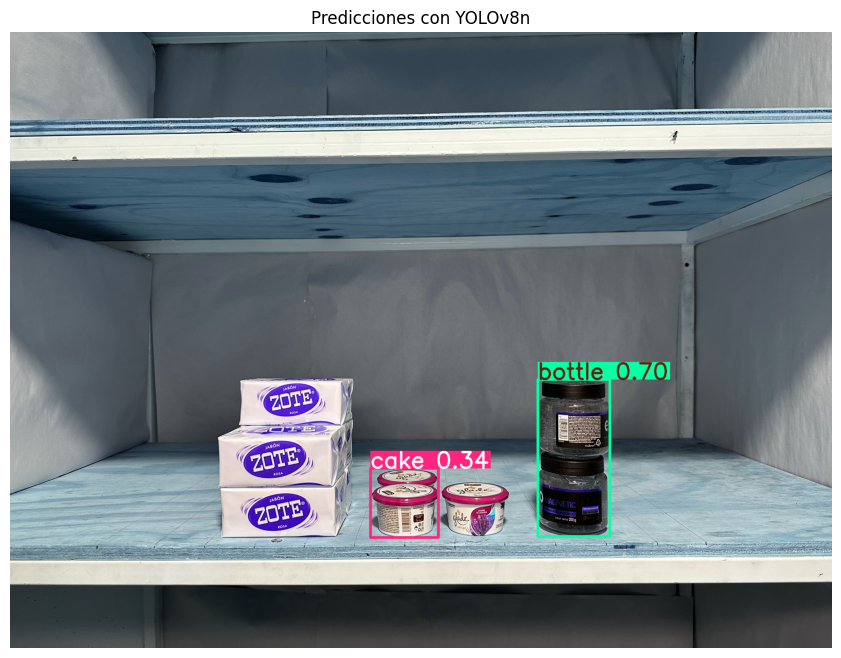

In [7]:
annotated_img = result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("Predicciones con YOLOv8n")
plt.show()

## 6. Extracción de predicciones en DataFrame

In [8]:
boxes = result.boxes
names = model.names

predictions = []

for box in boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    conf = float(box.conf[0].cpu().numpy())
    cls_id = int(box.cls[0].cpu().numpy())
    cls_name = names[cls_id]

    predictions.append({
        "class_id": cls_id,
        "class_name": cls_name,
        "confidence": conf,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
        "width": x2 - x1,
        "height": y2 - y1
    })

df_predictions = pd.DataFrame(predictions)

df_predictions

,class_id,class_name,confidence,x1,y1,x2,y2,width,height
0,39,bottle,0.703303,2589.169434,1705.716187,2942.271484,2476.530273,353.102051,770.814087
1,55,cake,0.339998,1768.229370,2141.468262,2101.926270,2481.018555,333.696899,339.550293


## 7. Conteo de objetos detectados por clase

In [9]:
if len(df_predictions) > 0:
    summary = (
        df_predictions
        .groupby("class_name")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
else:
    summary = pd.DataFrame(columns=["class_name", "count"])

summary

,class_name,count
0,bottle,1
1,cake,1


In [10]:
df_predictions.to_csv("predicciones_yolo_dataset_propio.csv", index=False)

print("Archivo guardado: predicciones_yolo_dataset_propio.csv")

Archivo guardado: predicciones_yolo_dataset_propio.csv


In [11]:
print(f"Número total de detecciones: {len(df_predictions)}")

if len(df_predictions) > 0:
    print("Clases detectadas:")
    display(summary)
else:
    print("No se detectaron objetos con el umbral de confianza seleccionado.")

Número total de detecciones: 2
Clases detectadas:


,class_name,count
0,bottle,1
1,cake,1
